In [2]:
#Importing libraries used
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
#Loading dataset
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

In [4]:
#Previewing first rows
print("Dataset Preview:")
print(df.head())

Dataset Preview:
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80 

In [5]:
#Standardising column names
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [6]:
#Converting sleep disorder column into binary (0=No,1=Yes)
df['sleep_disorder'] = df['sleep_disorder'].apply(lambda x: 0 if pd.isna(x) else 1)
print("\nClass Distribution:")
print(df["sleep_disorder"].value_counts())


Class Distribution:
sleep_disorder
0    219
1    155
Name: count, dtype: int64


In [7]:
average_sleep = df['sleep_duration'].mean()
average_stress = df['stress_level'].mean()

In [8]:
print("Average Sleep Duration:", round(average_sleep,2))
print("Average Stress Level:", round(average_stress,2))


Average Sleep Duration: 7.13
Average Stress Level: 5.39


In [9]:
#plotting of stress vs sleep
#plt.scatter(df['stress_level'], df['sleep_duration'])
#plt.xlabel("Stress Level")
#plt.ylabel("Sleep Duration")
#plt.title("Stress vs Sleep Duration")
#plt.show()

In [10]:
#Selecting numerical features relevant to prediction 
features = ['age', 'sleep_duration', 'quality_of_sleep',
            'stress_level', 'physical_activity_level', 
            'heart_rate','daily_steps']
X = df[features] #values that will be inputed(independent variable)
y = df['sleep_disorder'] # Target variable (dependent variable)

In [11]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


Training Samples: 299
Testing Samples: 75


In [13]:
#Model training 
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("\nModel Training Complete.")



Model Training Complete.


In [14]:
#Model Evaluation 
accuracy = model.score(X_test, y_test)
print("Model Accuracy:", round(accuracy*100, 2),"%")

Model Accuracy: 94.67 %


In [15]:
#Confusion Matrix
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

#Classification report
print("\nClassification Report:")
print(classification_report(y_test,y_pred))


Confusion Matrix:
[[42  1]
 [ 3 29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        43
           1       0.97      0.91      0.94        32

    accuracy                           0.95        75
   macro avg       0.95      0.94      0.95        75
weighted avg       0.95      0.95      0.95        75



In [16]:
importance = pd.DataFrame({
    "Feature":features,
    "Coefficient":model.coef_[0]}).sort_values(by="Coefficient")
                                               

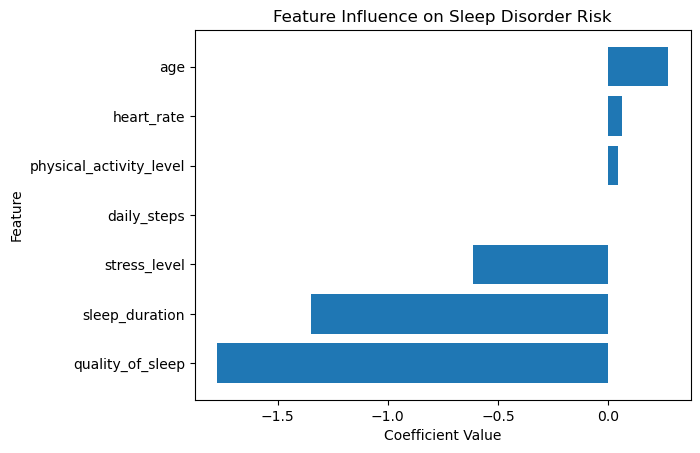

In [17]:
#Plotting
plt.figure()
plt.barh(importance["Feature"], importance["Coefficient"])
plt.title("Feature Influence on Sleep Disorder Risk")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

In [19]:
#Example input:
# [age, sleep_duration, quality_of_sleep,
#  physical_activity_level, stress_level,
#  heart_rate, daily_steps]

new_person = pd.DataFrame([{
    'age':25,
    'sleep_duration': 5,
    'quality_of_sleep': 4,
    'stress_level': 10,
    'physical_activity_level': 10,
    'heart_rate': 100,
    'daily_steps': 8000
}])

prediction = model.predict(new_person)
probability = model.predict_proba(new_person)

print("\nNew Person Prediction:")
print("Predicted Class (0 = No Disorder, 1 = Disorder):", prediction[0])
print("Probability of Disorder:", round(probability[0][1], 2))


New Person Prediction:
Predicted Class (0 = No Disorder, 1 = Disorder): 0
Probability of Disorder: 0.4
